In [1]:
# 24.08.2026, kontynuacja - Maciek zauwazyl (w rozmowie z Claude'em), ze
# "anomalia cyklu 2008" opisana w 20260824a.ipynb (Czesc B) moze byc
# artefaktem SZTYWNEGO, NIENACHODZACEGO podzialu na cykle: klaster nie
# nalezy do zadnego z dwoch cykli z osobna, tylko LEZY NA GRANICY miedzy
# cyklem 1996 a 2008 (2008-11-01) i zostaje przez ta granice rozciety na
# dwie czesci - "ogon" w panelu cyklu 1996 (juz wczesniej zauwazony w
# 20260823b.ipynb jako podejrzana gwiazdka na skraju danych, t=12.3 roku)
# i "poczatek" w panelu cyklu 2008 (dzisiejszy "kliff+plateau" z
# 20260824a.ipynb).
#
# Test (Maciek: "zrobmy to"): zamiast patrzec na kazdy cykl OSOBNO (co
# resetuje os czasu do zera na kazdej granicy), sklejamy sasiadujace pary
# cykli w JEDNA ciagla os KALENDARZOWA (bez resetu) i sprawdzamy, czy
# "klaster" faktycznie przechodzi PLYNNIE przez granice, czy to dwa
# niezalezne zjawiska. ZERO nowych obliczen - to samo zrodlo danych co
# 20260824a.ipynb (results/cycle_scan_*.csv + results/pgrid_scan_*.csv),
# tylko inny sposob sklejania/wizualizacji.
#
# Przy okazji (tanio, ta sama petla) sprawdzamy WSZYSTKIE 5 sasiadujacych
# par cykli (nie tylko 1996/2008) - zeby odpowiedziec na pytanie, czy to
# OGOLNY artefakt segmentacji (kazda granica cieloby cos podobnego) czy
# cos SZCZEGOLNEGO wlasnie dla przejscia 1996->2008 (spojne z tym, ze to
# przejscie zawiera rekordowo glebokie minimum sloneczne 2008-2009, patrz
# 20260820.txt).
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"

STATIONS_22 = ["mosc", "oulu"] + [
    s.lower() for s in [
        "THUL", "LMKS", "APTY", "SOPB", "JUNG1", "SOPO", "FSMT",
        "JUNG", "NEWK", "PWNK", "MXCO", "NAIN", "HRMS", "TERA", "INVK", "ATHN",
        "AATB", "PSNM", "NANM", "MCRL",
    ]
]
STATIONS_5 = ["mosc", "oulu", "athn", "hrms", "sopb"]

CYCLE_BOUNDS = {
    "cycle_1964": ("1965-01-01", "1976-02-01"),
    "cycle_1976": ("1976-02-01", "1986-05-01"),
    "cycle_1986": ("1986-05-01", "1996-06-01"),
    "cycle_1996": ("1996-06-01", "2008-11-01"),
    "cycle_2008": ("2008-11-01", "2019-09-01"),
    "cycle_2019_incomplete": ("2019-09-01", "2025-01-31"),
}
CYCLE_ORDER = list(CYCLE_BOUNDS)
CYCLE_START = {c: pd.Timestamp(s) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_END = {c: pd.Timestamp(e) for c, (s, e) in CYCLE_BOUNDS.items()}

# Sasiadujace pary (granica = koniec pierwszego = poczatek drugiego).
TRANSITIONS = [(CYCLE_ORDER[i], CYCLE_ORDER[i + 1]) for i in range(len(CYCLE_ORDER) - 1)]
for a, b in TRANSITIONS:
    boundary = CYCLE_END[a]
    assert boundary == CYCLE_START[b]
    print(f"{a} -> {b}: granica {boundary.date()}")

cycle_1964 -> cycle_1976: granica 1976-02-01
cycle_1976 -> cycle_1986: granica 1986-05-01
cycle_1986 -> cycle_1996: granica 1996-06-01
cycle_1996 -> cycle_2008: granica 2008-11-01
cycle_2008 -> cycle_2019_incomplete: granica 2019-09-01


In [2]:
# Wczytanie 5 stacji reprezentatywnych x 8 wartosci P_days (identyczne
# zrodlo co 20260824a.ipynb Czesc B), WSZYSTKIE cykle (potrzebne do
# sklejania sasiadujacych par).
FILENAME_RE_5 = re.compile(
    r"^(?P<prefix>cycle_scan|pgrid_scan)_(?P<station>[a-z]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)


def parse_5(path):
    m = FILENAME_RE_5.match(os.path.basename(path))
    if not m or m["station"] not in STATIONS_5 or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames_5 = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv")) +
                    glob.glob(os.path.join(RESULTS_DIR, "pgrid_scan_*.csv"))):
    meta = parse_5(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames_5.append(df)

all_candidates_5 = pd.concat(frames_5, ignore_index=True)
print(f"5 stacji: wczytano {len(all_candidates_5)} wierszy z {len(frames_5)} plikow")

# Wczytanie 22 stacji x P_days w {1675, 3350} - jak w 20260824a.ipynb Czesc A.
FILENAME_RE_22 = re.compile(
    r"^cycle_scan_(?P<station>[a-z0-9]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)
P_DAYS_22 = [1675, 3350]


def parse_22(path):
    m = FILENAME_RE_22.match(os.path.basename(path))
    if not m or int(m["Pdays"]) not in P_DAYS_22 or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames_22 = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_22(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames_22.append(df)

all_candidates_22 = pd.concat(frames_22, ignore_index=True)
print(f"22 stacje: wczytano {len(all_candidates_22)} wierszy z {len(frames_22)} plikow")

5 stacji: wczytano 1196172 wierszy z 344 plikow
22 stacje: wczytano 1206908 wierszy z 384 plikow


In [3]:
# Dla pary sasiadujacych cyklow (a, b): sklejamy dane OBU paneli na JEDNA
# ciagla os kalendarzowa (od poczatku a do konca b, BEZ resetu przy
# granicy) - x = rzeczywista data t0, nie "lata od startu wlasnego cyklu".
# Wiersze = dostepne P_days, wartosc = mediana -log10(PPDF) po dostepnych
# stacjach. Dodatkowo per wiersz: pozycja i wartosc GLOBALNEGO maksimum w
# calym sklejonym oknie (moze wypasc po ktorejkolwiek stronie granicy -
# to jest kluczowa roznica wzgledem 20260824a.ipynb, gdzie kazdy panel byl
# liczony OSOBNO i granica automatycznie obcinala dane).
def build_transition_heatmap(cycle_a, cycle_b, data, p_days_list, d):
    both = data[(data["cycle"].isin([cycle_a, cycle_b])) & (data["d"] == d)]
    t0_ref = pd.date_range(CYCLE_START[cycle_a], CYCLE_END[cycle_b], freq="24h")
    boundary = CYCLE_END[cycle_a]

    available_p = [p for p in p_days_list if p in both["P_days"].unique()]
    mat = np.full((len(available_p), len(t0_ref)), np.nan)
    peaks = []
    for i, P_days in enumerate(available_p):
        sub = both[both["P_days"] == P_days]
        med_ppdf = sub.groupby("t0")["PPDF"].median().reindex(t0_ref)
        with np.errstate(divide="ignore"):
            mat[i] = -np.log10(np.clip(med_ppdf.to_numpy(dtype=float), 1e-300, None))
        if np.isfinite(mat[i]).any():
            ti = np.nanargmax(mat[i])
            peaks.append(dict(
                P_days=P_days, t0=t0_ref[ti],
                days_from_boundary=(t0_ref[ti] - boundary).days,
                neglog10_ppdf=mat[i][ti],
            ))
    return t0_ref, boundary, available_p, mat, pd.DataFrame(peaks)

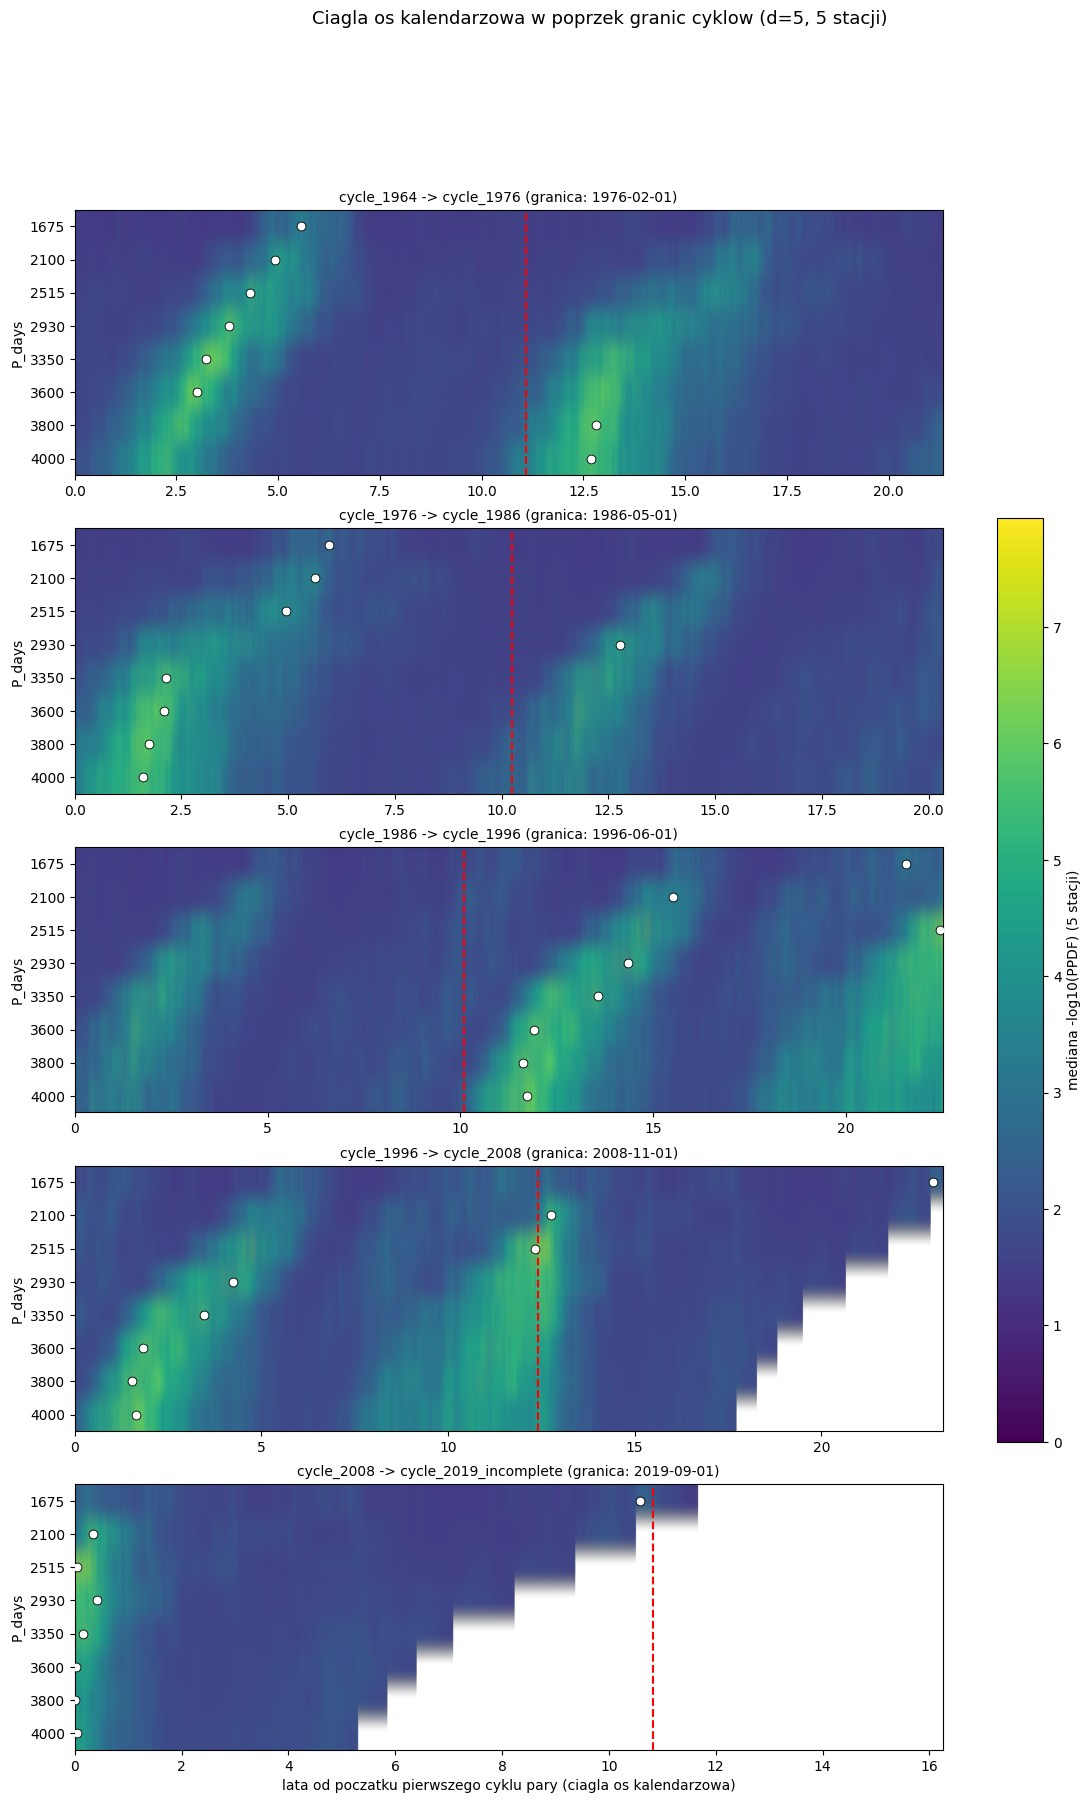

In [4]:
# Wykres dla WSZYSTKICH 5 przejsc naraz, jeden panel na przejscie, wspolny
# colorbar. Czerwona pionowa PRZERYWANA linia = granica cyklu (miejsce,
# gdzie SZTYWNY podzial obcinalby dane na dwa osobne panele w
# 20260824a.ipynb). Bialy punkt = pozycja globalnego maksimum w kazdym
# wierszu P_days (jesli lezy blisko czerwonej linii i jest SPOJNY miedzy
# sasiednimi wartosciami P_days - to argument ZA hipoteza Maćka, ze to
# jeden ciagly klaster, nie artefakt segmentacji; jesli skacze w rozne
# miejsca bez wzorca - argument PRZECIW).
P_DAYS_5_GRID = [1675, 2100, 2515, 2930, 3350, 3600, 3800, 4000]


def plot_all_transitions(data, p_days_list, d, station_label, save_suffix):
    fig, axes = plt.subplots(len(TRANSITIONS), 1, figsize=(14, 4 * len(TRANSITIONS)))
    results = {}
    for a, b in TRANSITIONS:
        results[(a, b)] = build_transition_heatmap(a, b, data, p_days_list, d)

    vmax = 0.0
    for t0_ref, boundary, available_p, mat, peaks in results.values():
        if np.isfinite(mat).any():
            vmax = max(vmax, np.nanmax(mat))

    im = None
    for ax, (a, b) in zip(axes, TRANSITIONS):
        t0_ref, boundary, available_p, mat, peaks = results[(a, b)]
        if len(available_p) == 0:
            ax.set_visible(False)
            continue
        years = (t0_ref - t0_ref[0]).days / 365.25
        im = ax.imshow(
            mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax,
            extent=[years.min(), years.max(), len(available_p) - 0.5, -0.5],
        )
        ax.set_yticks(range(len(available_p)))
        ax.set_yticklabels(available_p)
        ax.set_ylim(len(available_p) - 0.5, -0.5)
        boundary_years = (boundary - t0_ref[0]).days / 365.25
        ax.axvline(boundary_years, color="red", ls="--", lw=1.5)
        if len(peaks):
            peak_years = (peaks["t0"] - t0_ref[0]).dt.days / 365.25
            row_of = {p: i for i, p in enumerate(available_p)}
            ax.scatter(peak_years, peaks["P_days"].map(row_of), s=40, color="white",
                       edgecolor="black", linewidth=0.6, zorder=5)
        ax.set_title(f"{a} -> {b} (granica: {boundary.date()})", fontsize=10)
        ax.set_ylabel("P_days")
    axes[-1].set_xlabel("lata od poczatku pierwszego cyklu pary (ciagla os kalendarzowa)")
    if im is not None:
        fig.colorbar(im, ax=axes, label=f"mediana -log10(PPDF) ({station_label})", shrink=0.6)
    fig.suptitle(f"Ciagla os kalendarzowa w poprzek granic cyklow (d={d}, {station_label})", fontsize=13)
    fig.savefig(f"{RESULTS_DIR}/transition_heatmap_{save_suffix}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return results


results_5_d5 = plot_all_transitions(all_candidates_5, P_DAYS_5_GRID, 5, "5 stacji", "5stations_d5")

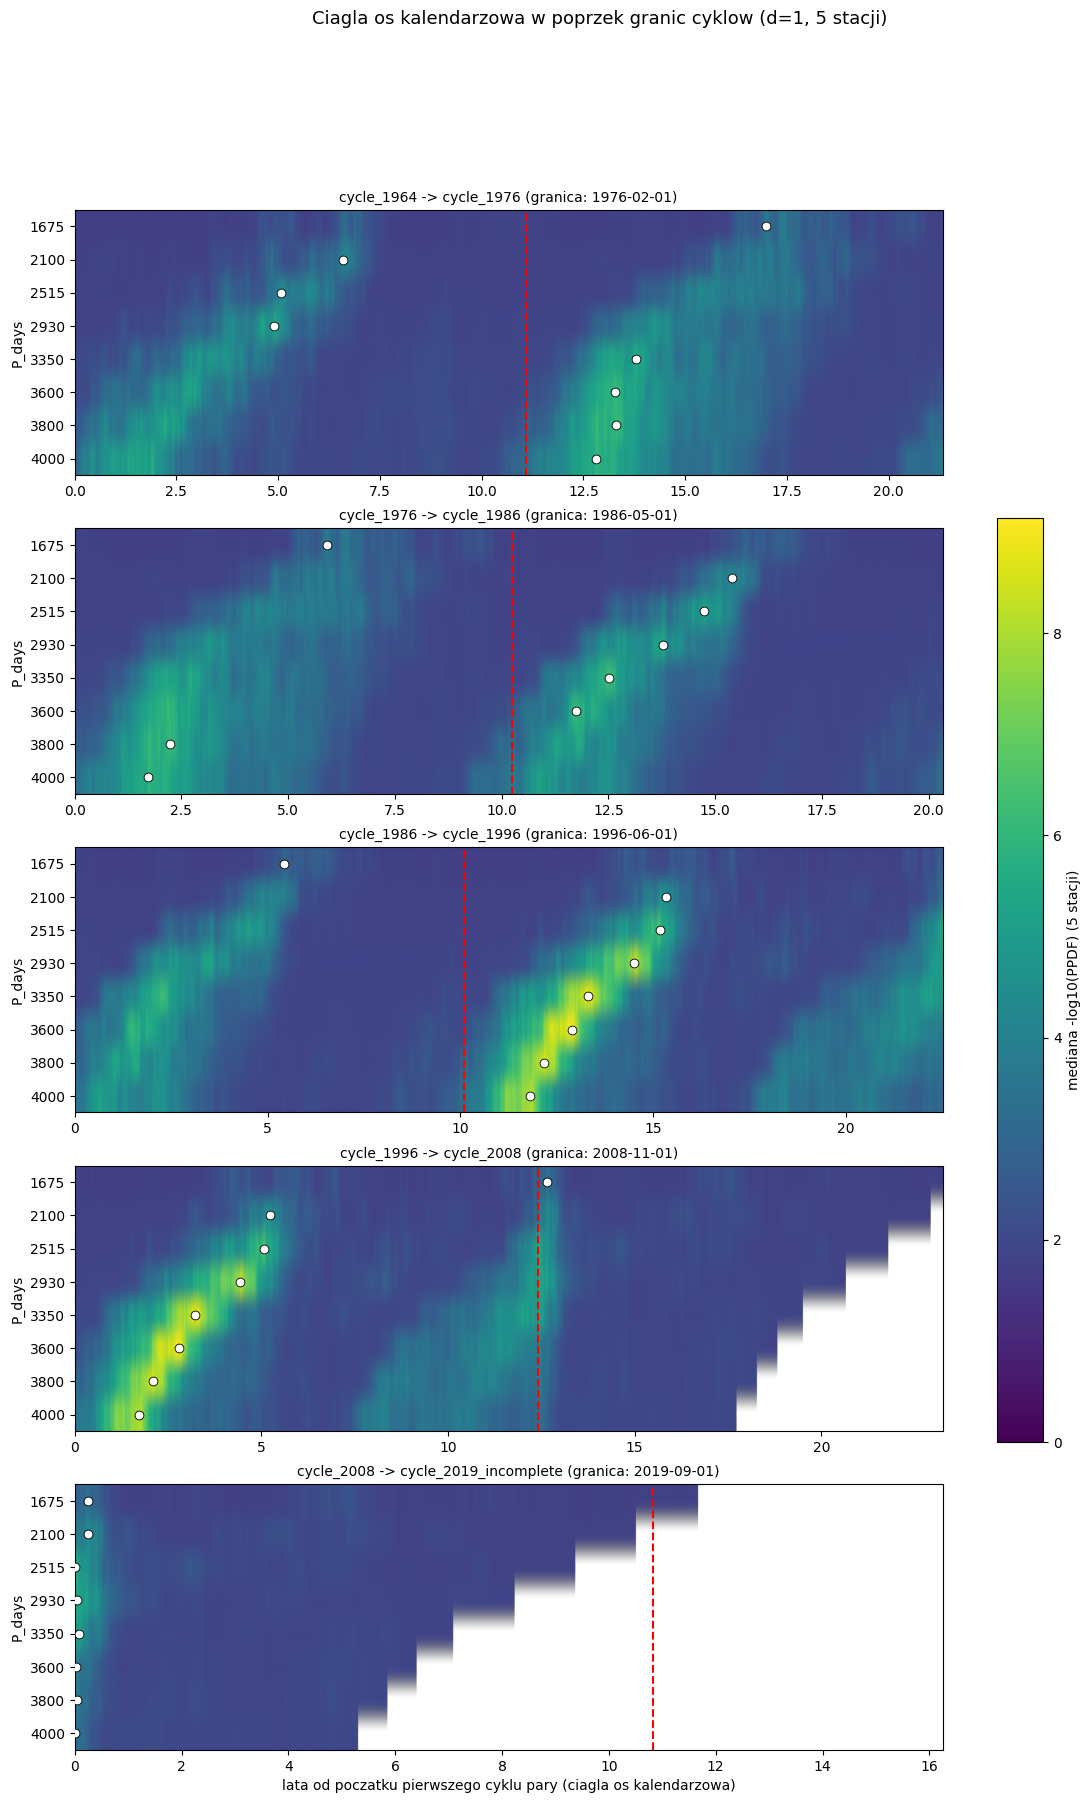

In [5]:
# To samo dla d=1 (kontrola przy innej szerokosci binu).
results_5_d1 = plot_all_transitions(all_candidates_5, P_DAYS_5_GRID, 1, "5 stacji", "5stations_d1")

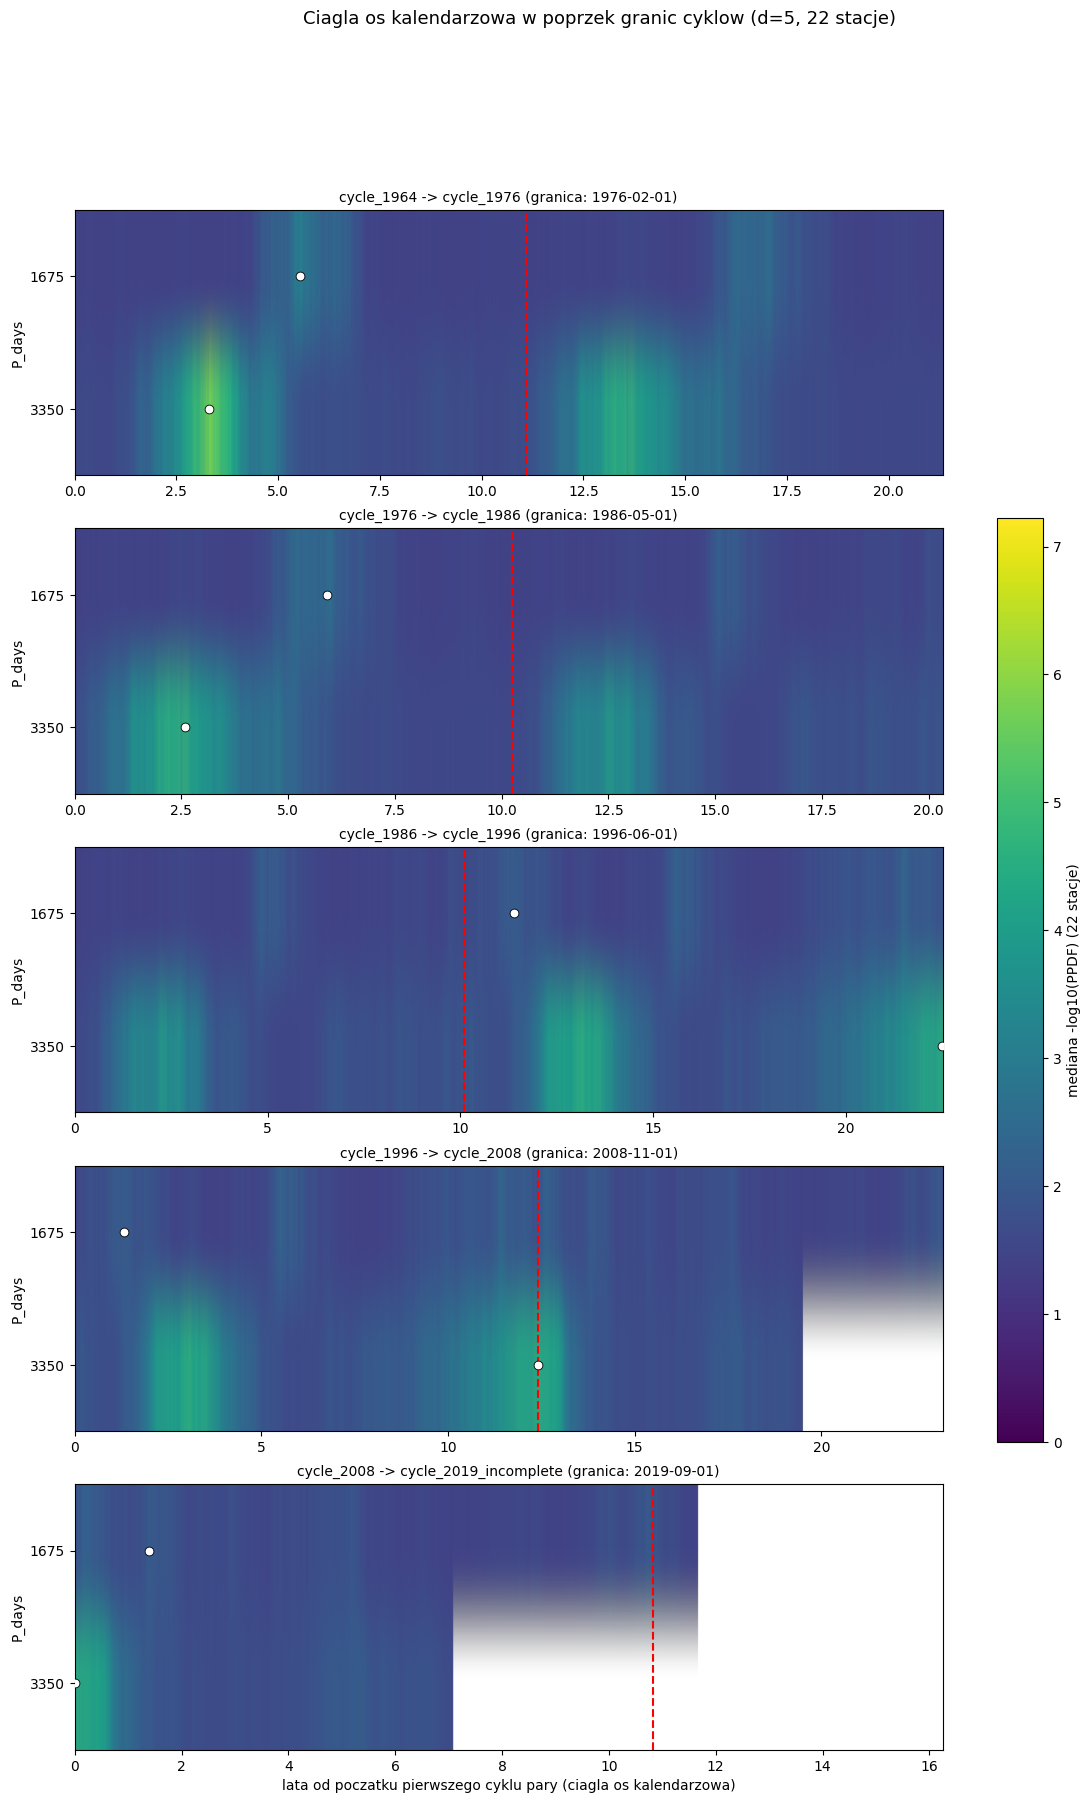

In [6]:
# To samo, ale na PELNYM zestawie 22 stacji (tylko P_days w {1675, 3350} -
# tyle mamy dla wszystkich 22) - kontrola, czy obraz z 5 stacji nie jest
# wlasnoscia akurat tego (potencjalnie stronniczego) wyboru stacji, zgodnie
# z ta sama logika co Czesc A z 20260824a.ipynb.
results_22_d5 = plot_all_transitions(all_candidates_22, [1675, 3350], 5, "22 stacje", "22stations_d5")

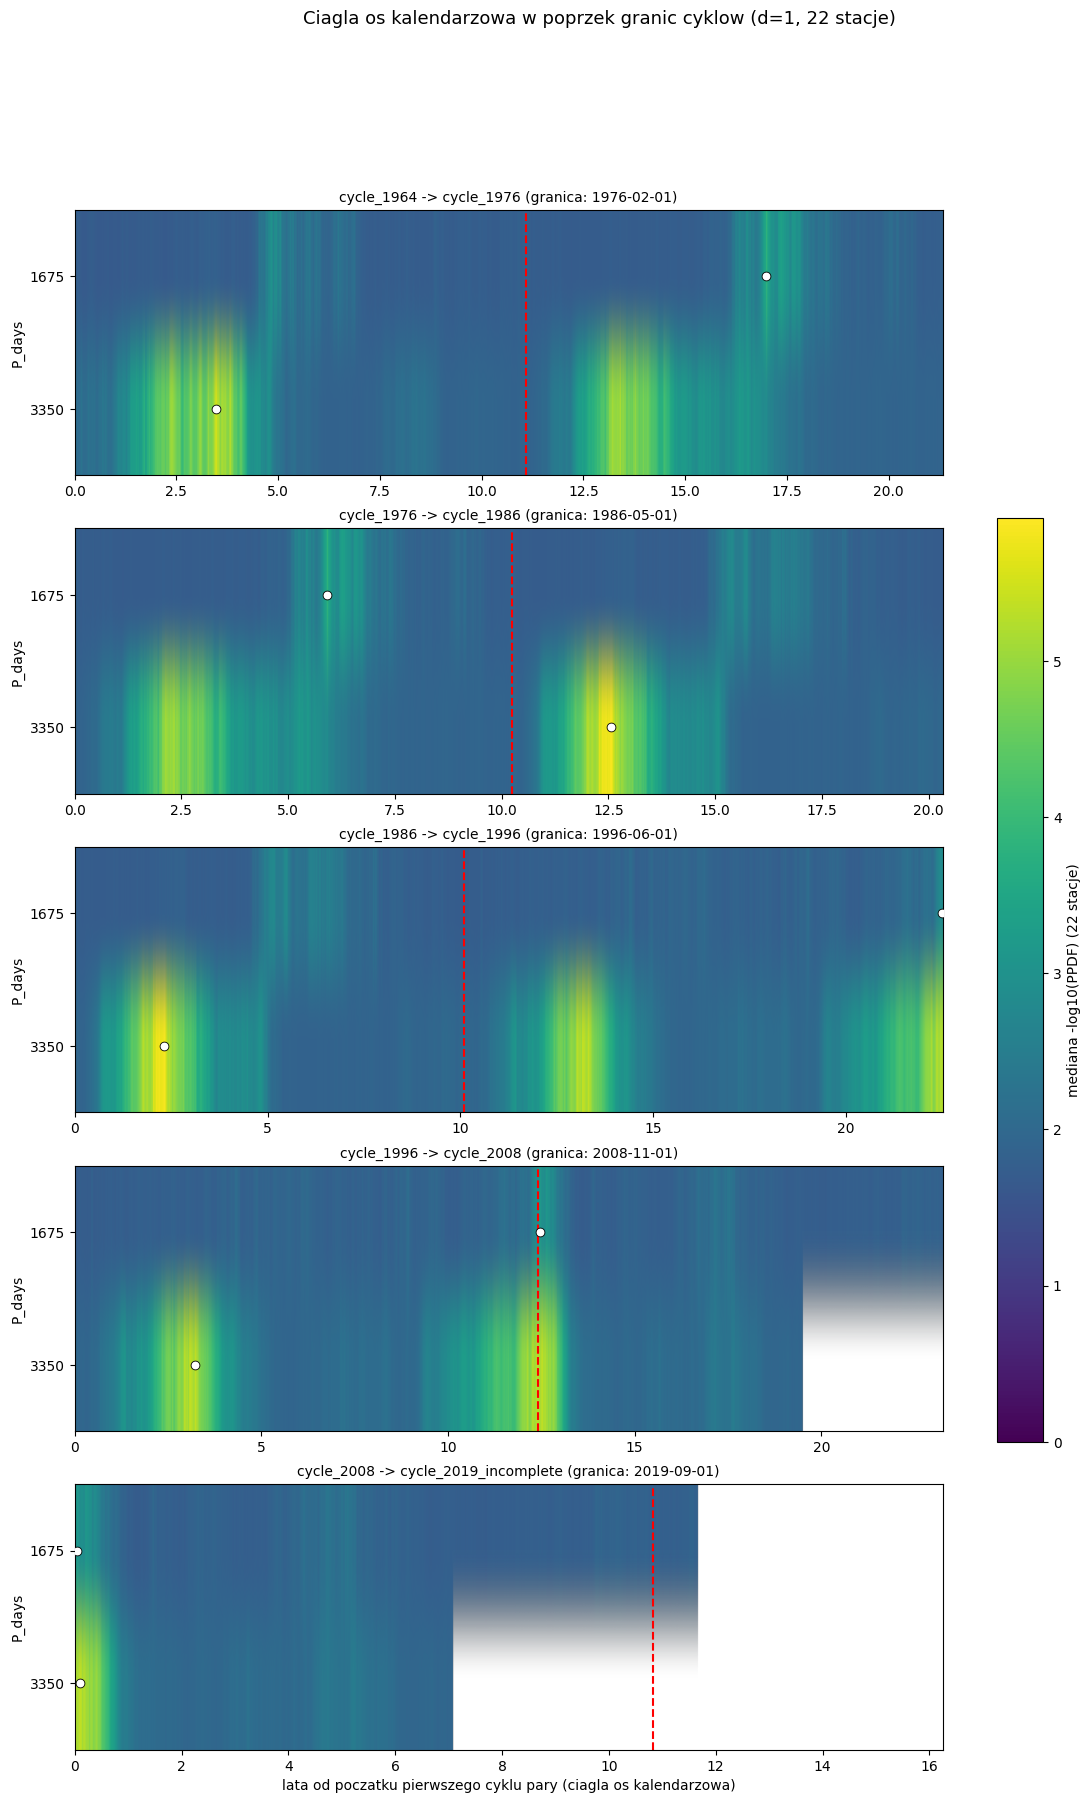

In [7]:
results_22_d1 = plot_all_transitions(all_candidates_22, [1675, 3350], 1, "22 stacje", "22stations_d1")

In [8]:
# Tabela liczbowa: dla kazdego przejscia x P_days x d x (5/22 stacje) - jak
# daleko (w dniach) od granicy lezy globalne maksimum sklejonego okna i jak
# silne jest. Male |days_from_boundary| dla WIELU kolejnych wartosci P_days
# W TYM SAMYM przejsciu = klaster "przyklejony" do granicy niezaleznie od
# P_days (spojne z hipoteza Maćka - jeden realny klaster kalendarzowy w
# okolicy tej konkretnej daty). Rozrzucone/przypadkowe pozycje w innych
# przejsciach = tamta granica nie ma szczegolnego znaczenia, wiec to NIE
# jest ogolny artefakt segmentacji dotykajacy kazdej granicy jednakowo.
rows = []
for label, res in [("5stations_d5", results_5_d5), ("5stations_d1", results_5_d1),
                    ("22stations_d5", results_22_d5), ("22stations_d1", results_22_d1)]:
    stations_label, d_label = label.split("stations_d")
    for (a, b), (t0_ref, boundary, available_p, mat, peaks) in res.items():
        for _, row in peaks.iterrows():
            rows.append(dict(transition=f"{a}->{b}", d=int(d_label), stations=stations_label,
                              **row.to_dict()))

transition_summary = pd.DataFrame(rows).sort_values(["transition", "stations", "d", "P_days"])
pd.set_option("display.width", 160)
print(transition_summary.to_string(index=False))
transition_summary.to_csv(f"{RESULTS_DIR}/transition_peak_summary.csv", index=False)

                       transition  d stations  P_days         t0  days_from_boundary  neglog10_ppdf
           cycle_1964->cycle_1976  1       22    1675 1981-12-30                2159       3.973645
           cycle_1964->cycle_1976  1       22    3350 1968-06-19               -2783       5.652078
           cycle_1964->cycle_1976  5       22    1675 1970-07-17               -2025       3.551825
           cycle_1964->cycle_1976  5       22    3350 1968-04-19               -2844       7.225297
           cycle_1964->cycle_1976  1        5    1675 1981-12-29                2158       3.973645
           cycle_1964->cycle_1976  1        5    2100 1971-08-10               -1636       4.314272
           cycle_1964->cycle_1976  1        5    2515 1970-01-26               -2197       4.604278
           cycle_1964->cycle_1976  1        5    2930 1969-11-28               -2256       5.641666
           cycle_1964->cycle_1976  1        5    3350 1978-10-15                 987       5.815959
